# Entraînement d'un cnn sur le dataset des images faiblement labellisées à la 1ère étape

In [1]:
# Chargement du dataset

import pandas as pd

df_weak = pd.read_csv("artifacts/weak_labels.csv")

print(df_weak.head())
print(df_weak.shape)

                                            filepath  cluster  weak_label  \
0  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        0           1   
1  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        1           0   
2  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        0           1   
3  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        0           1   
4  \Users\emman\Formation\P7 SSL\mri_dataset_brai...        0           1   

    distance  
0  21.356153  
1  14.821634  
2  15.216763  
3  18.389330  
4  17.828232  
(663, 4)


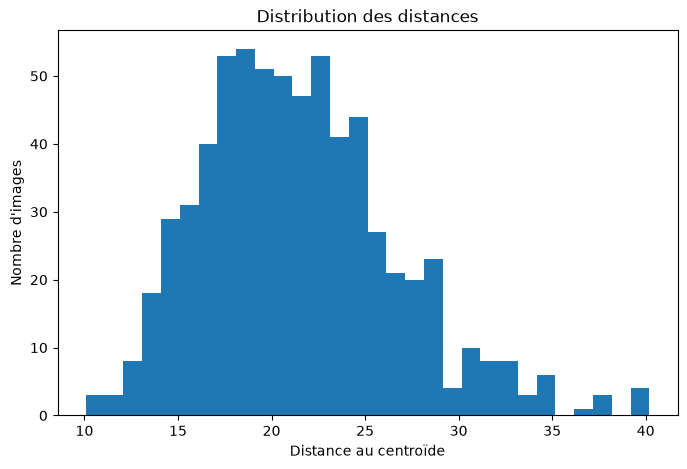

In [2]:
# On cherche à optimiser les distances entre les données et les centroïdes KMeans
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_weak["distance"], bins=30)
plt.xlabel("Distance au centroïde")
plt.ylabel("Nombre d'images")
plt.title("Distribution des distances")
plt.show()

In [3]:
# Filtrage par cluster
def kmeans_conf (df_weak, quantile):
    df_weak_conf = (
        df_weak
        .groupby("cluster", group_keys=False)
        .apply(
            lambda x:
            x[x["distance"] <= x["distance"].quantile(quantile)]
        )
        .reset_index(drop=True)
    )

    print(len(df_weak_conf))
    print(
        df_weak_conf["weak_label"].value_counts()
    )
    return df_weak_conf

In [4]:
df_weak_100 = kmeans_conf(df_weak,1.00)
df_weak_90 = kmeans_conf(df_weak,0.90)
df_weak_80 = kmeans_conf(df_weak,0.80)

663
weak_label
0    476
1    187
Name: count, dtype: int64
597
weak_label
0    428
1    169
Name: count, dtype: int64
530
weak_label
0    381
1    149
Name: count, dtype: int64


In [5]:
df_weak_80["weak_label"].value_counts()
df_weak_80["weak_label"].value_counts(normalize=True)

df_weak_90["weak_label"].value_counts()
df_weak_90["weak_label"].value_counts(normalize=True)

df_weak_100["weak_label"].value_counts()
df_weak_100["weak_label"].value_counts(normalize=True)

weak_label
0    0.717949
1    0.282051
Name: proportion, dtype: float64

In [9]:
# Récupération du df avec images labellisées en vue top
from pathlib import Path
import pandas as pd

ROOT = Path(r"C:\Users\emman\Formation\P7 SSL\mri_dataset_brain_cancer_oc\avec_labels")

rows = []

for label_name, label in [("normal", 0), ("cancer", 1)]:

    folder = ROOT / label_name / "top"

    for ext in ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif"]:
        for img_path in folder.glob(ext):
            rows.append({
                "filepath": str(img_path),
                "label": label
            })

df_lab = pd.DataFrame(rows)

print(df_lab.shape)
df_lab.head()

(70, 2)


,filepath,label
0,C:\Users\emman\Formation\P7 SSL\mri_dataset_br...,0
1,C:\Users\emman\Formation\P7 SSL\mri_dataset_br...,0
2,C:\Users\emman\Formation\P7 SSL\mri_dataset_br...,0
3,C:\Users\emman\Formation\P7 SSL\mri_dataset_br...,0
4,C:\Users\emman\Formation\P7 SSL\mri_dataset_br...,0


In [ ]:
# Split du jeu labellisé
from sklearn.model_selection import train_test_split

df_train_strong, df_test = train_test_split(
    df_lab,
    test_size=0.20,
    stratify=df_lab["label"],
    random_state=42
)

In [42]:
# Changement de méthode pour le split
from sklearn.model_selection import StratifiedKFold

X = df_lab.drop(columns=["label"])
y = df_lab["label"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    df_train_strong = df_lab.iloc[train_idx]
    df_test = df_lab.iloc[test_idx]

    print(f"Fold {fold}")


Fold 0
Fold 1
Fold 2
Fold 3
Fold 4


In [44]:
print(len(df_train_strong))
print(len(df_test))

print(df_test["label"].value_counts())
print(df_train_strong["label"].value_counts())

56
14
label
0    9
1    5
Name: count, dtype: int64
label
0    39
1    17
Name: count, dtype: int64


In [40]:
# Prépa fichier weak_labels
df_weak_train = df_weak_80.rename(
    columns={"weak_label": "label"}
)
df_weak_train.head()

,filepath,label,distance
0,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,1,21.356153
1,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,1,15.216763
2,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,1,18.389330
3,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,1,17.828232
4,\Users\emman\Formation\P7 SSL\mri_dataset_brai...,1,18.576025


In [1]:
# Modélisation avec PyTorch
import torch
from torch.utils.data import Dataset
from PIL import Image

class BrainDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img = Image.open(
            row["filepath"]
        ).convert("L")

        if self.transform:
            img = self.transform(img)

        label = int(row["label"])

        return img, label

In [2]:
# Transformation du train
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [3]:
# Transformation du test
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [45]:
weak_dataset = BrainDataset(
    df_weak_train,
    train_transform
)

strong_train_dataset = BrainDataset(
    df_train_strong,
    train_transform
)

test_dataset = BrainDataset(
    df_test,
    test_transform
)

In [46]:
# Chargement
from torch.utils.data import DataLoader

weak_loader = DataLoader(
    weak_dataset,
    batch_size=16,
    shuffle=True
)

strong_loader = DataLoader(
    strong_train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [47]:
# Chargement de ResNet50

from torchvision.models import (
    resnet50,
    ResNet50_Weights
)
import torch.nn as nn

model = resnet50(
    weights=ResNet50_Weights.IMAGENET1K_V2
)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

In [48]:
# Gel des couches
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [49]:
# Paramétrage device
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = model.to(device)

In [50]:
# Perte et optim
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

In [51]:
# Fonction d'entraînement
def train_epoch(loader):

    model.train()

    running_loss = 0

    for imgs, labels in loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [52]:
# Pré-entraînement sur les labels faibles
for epoch in range(10):

    loss = train_epoch(
        weak_loader
    )

    print(
        epoch + 1,
        loss
    )

1 0.4099971998263808
2 0.2250155883238596
3 0.20178795408676653
4 0.16944819294354496
5 0.13843701494967237
6 0.14889459016130252
7 0.15224754980162664
8 0.11262798194280442
9 0.11646964461268748
10 0.10498377653386663


In [53]:
# Fine tuning sur les labels forts
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5
)

for epoch in range(10):

    loss = train_epoch(
        strong_loader
    )

    print(
        epoch + 1,
        loss
    )

1 0.337398212403059
2 0.23273476585745811
3 0.29002662748098373
4 0.24309812672436237
5 0.2546941265463829
6 0.16795957647264004
7 0.270141065120697
8 0.1750015988945961
9 0.14550740830600262
10 0.14697884395718575


In [14]:
# Evaluation
from sklearn.metrics import (
    classification_report,
    f1_score
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)

        outputs = model(imgs)

        preds = outputs.argmax(1)

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

print(
    classification_report(
        y_true,
        y_pred
    )
)
f1_semi = f1_score(y_true, y_pred)

print(
    "F1 :",
    f1_semi
)

              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.80      0.89         5

    accuracy                           0.93        14
   macro avg       0.95      0.90      0.92        14
weighted avg       0.94      0.93      0.93        14

F1 : 0.8888888888888888


In [ ]:
# Vérification données test
test_paths = set(df_test["filepath"])
weak_paths = set(df_weak_80["filepath"])

print(
    len(test_paths.intersection(
        weak_paths
    ))
)

0


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[10  0]
 [ 0  4]]


# Entrainement supervisé des labels forts

In [4]:
# Fonction d'évaluation
from sklearn.metrics import f1_score
import torch

def evaluate(model, loader, device):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    return f1_score(y_true, y_pred)

In [5]:
# Fonction d'entraînement
def train_epoch(model,
                loader,
                optimizer,
                criterion,
                device):

    model.train()

    running_loss = 0

    for imgs, labels in loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [6]:
# Construction du modèle
from torchvision.models import (
    resnet50,
    ResNet50_Weights
)
import torch.nn as nn

def build_model():

    model = resnet50(
        weights=ResNet50_Weights.IMAGENET1K_V2
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    return model

In [7]:
# Validation croisée
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader
import numpy as np

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

f1_scores = []

In [10]:
# Exécution par fold
for fold, (train_idx, test_idx) in enumerate(
        skf.split(df_lab,
                  df_lab["label"])):

    print(f"\nFold {fold+1}")

    df_train = (
        df_lab.iloc[train_idx]
        .reset_index(drop=True)
    )

    df_test = (
        df_lab.iloc[test_idx]
        .reset_index(drop=True)
    )

    train_dataset = BrainDataset(
        df_train,
        train_transform
    )

    test_dataset = BrainDataset(
        df_test,
        test_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    model = build_model().to(device)


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


In [11]:
# Entraînement do modèle
for param in model.parameters():
        param.requires_grad = False

for param in model.fc.parameters():
        param.requires_grad = True

optimizer = torch.optim.Adam(
model.fc.parameters(),
lr=1e-3
)

criterion = nn.CrossEntropyLoss()

for epoch in range(10):

    loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

In [12]:
# Fine tuning
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5
)

for epoch in range(10):

    loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

In [13]:
# Evaluation
f1 = evaluate(
    model,
    test_loader,
    device
)

print(f"F1 : {f1:.3f}")

f1_scores.append(f1)

print(
    f"\nF1 moyen : "
    f"{np.mean(f1_scores):.3f}"
)

print(
    f"Écart-type : "
    f"{np.std(f1_scores):.3f}"
)

F1 : 0.889

F1 moyen : 0.889
Écart-type : 0.000


In [15]:
# Comparaison des entraînements semi-supervisé et supervisé
print(
    f"Supervisé      : "
    f"{np.mean(f1_scores):.3f}"
)

print(
    f"Semi-supervisé : "
    f"{np.mean(f1_semi):.3f}"
)

Supervisé      : 0.889
Semi-supervisé : 0.889
